**6/29/2026**

**BreastDM_DataProcessing**

This notebook is going to be my notebook for all my data processing stuff. BreastDM_CW is just going to be general processing for other applications.

Currently the code in this ipynb file does:

*   Setup and Unzipping // It initializes by importing necessary libraries, mounts Google Drive, and unzips the main dataset from a .zip file.
*   Initial Data Inspection // The code then looks at the directory structure of the unzipped dataset and loads a sample .npy file to understand its data type, shape, and value range. This makes it easy to see how far I am and how far I need to go to make it the desired structure.
*   Classification Data Organization // Processes .npy files to organize them into distinct 'Benign' and 'Malignant' directories, preparing the data for a classification task.
*   Segmentation Data Processing and Visualization // Identifies 3D image and mask .npy volumes from the segmentation part of the dataset, extracts a central 2D slice from each, and displays these slices for visual inspection.
*   Segmentation Data Conversion // Finally, it converts these extracted 2D slices from .npy format into .png image files, scaling their pixel values, and saving them into separate 'images' and 'masks' directories for segmentation tasks.









In [20]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
import shutil
from PIL import Image


In [21]:
# Mount

drive.mount('/content/drive')
drive.mount('/content/drive', force_remount = True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted at /content/drive


In [22]:
# Dataset path
DATASET = "/content/drive/MyDrive/BreastDM_Project/data/BreastDMDS.zip"

# little testing

root = DATASET

max_depth = 3

for current_path, dirs, files in os.walk(root):

  # deepness?

  depth = current_path.replace(root,"").count(os.sep)
  if depth > max_depth:
      continue

      indent = "    "*depth

      # Folder name

      print(f"{indent}{os.path.basename(current_path)}/")

      # Print files from this folder

      file_indent = "    "*(depth+1)

      for file in files[:5]:
          print(f"{file_indent}{file}")
      # stop the spamming output
      if len(files) > 5:
          print(f'{file_indent}...({len(files)-5}) more files')

In [23]:
# I have unzip the file first!

unzip_path = '/content/BreastDMDS_unzipped'
os.makedirs(unzip_path, exist_ok=True)

with zipfile.ZipFile(DATASET, 'r') as zip_ref:
    zip_ref.extractall(unzip_path)

print(f"Dataset unzipped to: {unzip_path}")

# Update DATASET to point to the unzipped directory
# DATASET = unzip_path

Dataset unzipped to: /content/BreastDMDS_unzipped


### Locate the `BreastDMDS.zip` file

If the file was not found, it's possible the path or filename is incorrect. This cell will search for `.zip` files in your mounted Google Drive and help you identify the correct path.

In [24]:
import os

def find_zip_file(root_dir, filename_pattern):
    found_paths = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if filename_pattern.lower() in file.lower() and file.lower().endswith('.zip'):
                found_paths.append(os.path.join(root, file))
    return found_paths

# Search within the mounted Google Drive
gdrive_root = '/content/drive/MyDrive'
zip_files_found = find_zip_file(gdrive_root, 'BreastDMDS.zip')

if zip_files_found:
    print(f"Found {len(zip_files_found)} file(s) matching 'BreastDMDS.zip':")
    for i, path in enumerate(zip_files_found):
        print(f"  [{i+1}] {path}")

    if len(zip_files_found) == 1:
        # Assume this is the correct one and update DATASET
        DATASET = zip_files_found[0]
        print(f"\nUpdated DATASET variable to: {DATASET}")
    else:
        print("\nPlease select the correct path from the list above and manually update the 'DATASET' variable in the cell above (or copy the path and update it in the next cell).")
else:
    print(f"No files matching 'BreastDMDS.zip' found in '{gdrive_root}'. Please ensure the file exists and is correctly named in your Google Drive.")


Found 1 file(s) matching 'BreastDMDS.zip':
  [1] /content/drive/MyDrive/BreastDM_Project/data/BreastDMDS.zip

Updated DATASET variable to: /content/drive/MyDrive/BreastDM_Project/data/BreastDMDS.zip


If the `DATASET` variable was updated in the previous cell, you can now re-run the unzip cell (`5a77de7d`). If multiple files were found, please manually update the `DATASET` variable with the correct path before proceeding.

In [25]:
# little testing (corrected)

root = unzip_path

def dir_structure(root,maxdepth):
    for current_path, dirs, files in os.walk(root):

        depth = current_path.replace(root, "").count(os.sep)

        if depth > maxdepth: # Corrected: using 'maxdepth' parameter
            continue

        indent = "    " * depth

        # Folder name
        print(f"{indent}{os.path.basename(current_path)}/")

        # Print files from this folder
        file_indent = "    " * (depth + 1)

        for file in files[:5]:
            print(f"{file_indent}{file}")
        # stop the spamming output
        if len(files) > 5:
            print(f'{file_indent}...({len(files)-5}) more files')

print("============================2 Depth============================")
dir_structure(unzip_path,2)
# print("============================4 Depth============================")
# dir_structure(unzip_path,4) # this is for a more in depth look (too deep for visualiztion)

============================2 Depth============================
BreastDMDS_unzipped/
    seg/
        train/
        test/
        val/
    cls/
        img17Se/
        LBP/
        GLCM/
        img9Se/
    seg3D/
        train/
        test/
        val/


In [26]:
# Define the new root directory for the organized dataset
new_dataset_root = '/content/processed_dataset'
benign_dir = os.path.join(new_dataset_root, 'B')
malignant_dir = os.path.join(new_dataset_root, 'M')

# Create the new directories if they don't exist
os.makedirs(benign_dir, exist_ok=True)
os.makedirs(malignant_dir, exist_ok=True)

print(f"Created directories: {benign_dir} and {malignant_dir}")

# Iterate through the unzipped dataset to find and move .npy files
benign_count = 0
malignant_count = 0

for current_path, _, files in os.walk(unzip_path):
    for file_name in files:
        if file_name.endswith('.npy'):
            full_file_path = os.path.join(current_path, file_name)

            # Determine the classification from the path
            if 'Benign' in current_path:
                destination_path = os.path.join(benign_dir, file_name)
                shutil.move(full_file_path, destination_path)
                benign_count += 1
            elif 'Malignant' in current_path:
                destination_path = os.path.join(malignant_dir, file_name)
                shutil.move(full_file_path, destination_path)
                malignant_count += 1
            else:
                print(f"Warning: Could not classify file {full_file_path}. Skipping.")

print(f"\nFinished organizing files:")
print(f"  Moved {benign_count} Benign files to {benign_dir}")
print(f"  Moved {malignant_count} Malignant files to {malignant_dir}")

# DATASET is not updated here to maintain its independence.
print(f"\nNew dataset root for B/M classification: {new_dataset_root}")

Created directories: /content/processed_dataset/B and /content/processed_dataset/M

Finished organizing files:
  Moved 2790 Benign files to /content/processed_dataset/B
  Moved 7585 Malignant files to /content/processed_dataset/M

New dataset root for B/M classification: /content/processed_dataset


In [27]:
# Verify the new structure
# this is the same thing from the other cell that i printed the structure
# i just want to check to make sure it looks how i need it to

print("============================ Organized Dataset Structure ============================")
dir_structure(new_dataset_root, maxdepth=2)

print(f"\nTotal files in Benign folder: {len(os.listdir(os.path.join(new_dataset_root, 'B')))}")
print(f"Total files in Malignant folder: {len(os.listdir(os.path.join(new_dataset_root, 'M')))}")

============================ Organized Dataset Structure ============================
processed_dataset/
    M/
        p-091.npy
        p-074.npy
        p-010.npy
        p-087.npy
        p-055.npy
        ...(82) more files
    B/
        p-091.npy
        p-074.npy
        p-010.npy
        p-087.npy
        p-055.npy
        ...(73) more files

Total files in Benign folder: 78
Total files in Malignant folder: 87


In [28]:
# Looking at files because how do we even differentiate between mask

# We need to find an actual .npy file path from the unzipped directory

sample_file_path = None
for root_dir, _, files in os.walk(unzip_path):
    for file_name in files:
        if file_name.endswith('.npy'):
            sample_file_path = os.path.join(root_dir, file_name)
            break
    if sample_file_path:
        break

if sample_file_path:
    print(f"Found sample .npy file in unzipped directory: {sample_file_path}")
    try:
        # Load the .npy file
        data = np.load(sample_file_path)

        print(f"\nData type of the loaded array: {data.dtype}")
        print(f"Shape of the loaded array: {data.shape}")
        print(f"Example values (first 5 elements if 1D, or a slice if multi-dimensional):\n{data.flatten()[:5] if data.ndim > 0 else data}")

        # If it's a 2D or 3D array, we can try to visualize it later
        if data.ndim >= 2:
            print(f"Min value: {data.min()}, Max value: {data.max()}")

    except Exception as e:
        print(f"Error loading or inspecting {sample_file_path}: {e}")
else:
    print(f"No .npy files found in {unzip_path}")

Found sample .npy file in unzipped directory: /content/BreastDMDS_unzipped/seg3D/train/labels/BreaDM-Ma-1913/SUB2.npy

Data type of the loaded array: float64
Shape of the loaded array: (369, 369, 8)
Example values (first 5 elements if 1D, or a slice if multi-dimensional):
[0. 0. 0. 0. 0.]
Min value: 0.0, Max value: 255.0


Inspecting files from: /content/BreastDMDS_unzipped

Found sample image file: /content/BreastDMDS_unzipped/seg3D/train/images/BreaDM-Ma-1913/SUB2.npy
Found sample mask file: /content/BreastDMDS_unzipped/seg3D/train/labels/BreaDM-Ma-1913/SUB2.npy

Image Data type: float64
Image Shape: (369, 369, 8)
Image Min/Max: 0.0/255.0
Displaying a central slice of the image volume...


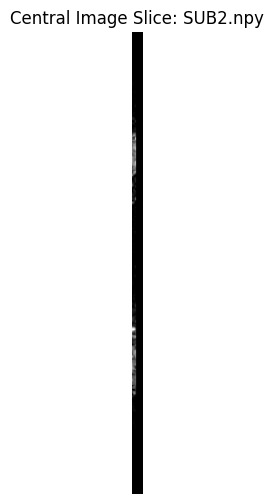


Mask Data type: float64
Mask Shape: (369, 369, 8)
Mask Min/Max: 0.0/255.0
Displaying a central slice of the mask volume...


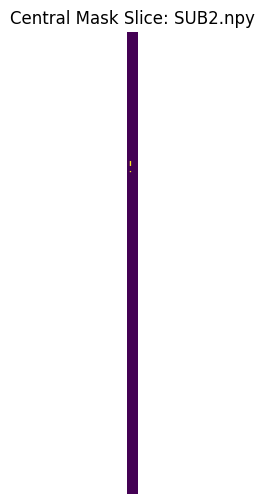

In [29]:
# Use unzip_path as the source for inspection
print(f"Inspecting files from: {unzip_path}")

image_file_path = None
mask_file_path = None

# Search for a sample image .npy file
for root_dir, _, files in os.walk(unzip_path):
    if 'seg3D' in root_dir and 'images' in root_dir:
        for file_name in files:
            if file_name.endswith('.npy'):
                image_file_path = os.path.join(root_dir, file_name)
                break
    if image_file_path:
        break

# Search for a sample mask .npy file
for root_dir, _, files in os.walk(unzip_path):
    if 'seg3D' in root_dir and 'labels' in root_dir:
        for file_name in files:
            if file_name.endswith('.npy'):
                mask_file_path = os.path.join(root_dir, file_name)
                break
    if mask_file_path:
        break

print(f"\nFound sample image file: {image_file_path}")
print(f"Found sample mask file: {mask_file_path}")

if image_file_path:
    try:
        image_data = np.load(image_file_path)
        print(f"\nImage Data type: {image_data.dtype}")
        print(f"Image Shape: {image_data.shape}")
        print(f"Image Min/Max: {image_data.min()}/{image_data.max()}")

        # Attempt to display a slice if it's a 3D volume
        if image_data.ndim == 3:
            print("Displaying a central slice of the image volume...")
            plt.figure(figsize=(6, 6))
            plt.imshow(image_data[image_data.shape[0] // 2, :, :], cmap='gray')
            plt.title(f'Central Image Slice: {os.path.basename(image_file_path)}')
            plt.axis('off')
            plt.show()
        elif image_data.ndim == 2:
            print("Displaying the 2D image...")
            plt.figure(figsize=(6, 6))
            plt.imshow(image_data, cmap='gray')
            plt.title(f'Image: {os.path.basename(image_file_path)}')
            plt.axis('off')
            plt.show()

    except Exception as e:
        print(f"Error loading or displaying image file {image_file_path}: {e}")

if mask_file_path:
    try:
        mask_data = np.load(mask_file_path)
        print(f"\nMask Data type: {mask_data.dtype}")
        print(f"Mask Shape: {mask_data.shape}")
        print(f"Mask Min/Max: {mask_data.min()}/{mask_data.max()}")

        # Attempt to display a slice if it's a 3D volume
        if mask_data.ndim == 3:
            print("Displaying a central slice of the mask volume...")
            plt.figure(figsize=(6, 6))
            plt.imshow(mask_data[mask_data.shape[0] // 2, :, :], cmap='viridis') # Use a different colormap for masks
            plt.title(f'Central Mask Slice: {os.path.basename(mask_file_path)}')
            plt.axis('off')
            plt.show()
        elif mask_data.ndim == 2:
            print("Displaying the 2D mask...")
            plt.figure(figsize=(6, 6))
            plt.imshow(mask_data, cmap='viridis')
            plt.title(f'Mask: {os.path.basename(mask_file_path)}')
            plt.axis('off')
            plt.show()

    except Exception as e:
        print(f"Error loading or displaying mask file {mask_file_path}: {e}")
else:
    if not image_file_path and not mask_file_path:
        print("No .npy image or mask files found in 'seg3D/images' or 'seg3D/labels' directories.")

In [30]:
# Define the new root directory for the organized segmentation dataset
# this is very similar to how the other segmentation directories work
segmentation_dataset_root = '/content/segmentation_dataset'
images_dir = os.path.join(segmentation_dataset_root, 'images')
masks_dir = os.path.join(segmentation_dataset_root, 'masks')

# Create the new directories if they don't exist
os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

print(f"Created directories: {images_dir} and {masks_dir}")

print(f"Processing files from: {unzip_path}")

processed_count = 0

# Iterate through the unzipped dataset
for root_dir, _, files in os.walk(unzip_path):
    # Look for 'images' and 'labels' directories within 'seg3D' splits
    if 'seg3D' in root_dir and ('images' in root_dir or 'labels' in root_dir):
        # Determine if it's an image or a mask directory
        is_image_dir = 'images' in root_dir

        # Extract split and patient_id for unique filenames
        # Example root_dir: /content/BreastDMDS_unzipped/seg3D/val/images/BreaDM-Be-2005
        try:
            # Split the path into components
            path_components = root_dir.split(os.sep)
            # Find the index of 'seg3D'
            seg3d_idx = path_components.index('seg3D')

            # The split (train/val/test) is after 'seg3D'
            split = path_components[seg3d_idx + 1]

            # The patient ID is after 'images' or 'labels'
            # Check if patient ID exists (for cases where root_dir might be just images/ or labels/)
            if len(path_components) > seg3d_idx + 3:
                patient_id = path_components[seg3d_idx + 3]
            else:
                patient_id = "unknown_patient" # Fallback if structure is unexpected

        except ValueError: # 'seg3D' not found or path structure is not as expected
            split = "unknown_split"
            patient_id = "unknown_patient"
        except IndexError: # Not enough components after seg3d_idx
            split = "unknown_split"
            patient_id = "unknown_patient"


        for file_name in files:
            if file_name.endswith('.npy'):
                original_base_name = os.path.splitext(file_name)[0] # Get filename without extension
                full_npy_path = os.path.join(root_dir, file_name)

                try:
                    data = np.load(full_npy_path)

                    # Handle 3D volumes by taking a central slice
                    if data.ndim == 3:
                        # Assuming the last dimension is the number of slices
                        central_slice_idx = data.shape[2] // 2
                        processed_data = data[:, :, central_slice_idx]
                    elif data.ndim == 2:
                        processed_data = data
                    else:
                        print(f"Skipping {full_npy_path}: Unsupported number of dimensions ({data.ndim})")
                        continue

                    # Scale data to 0-255 and convert to uint8 for PNG
                    # Ensure min/max are not identical to avoid division by zero
                    data_min = processed_data.min()
                    data_max = processed_data.max()

                    if data_max == data_min:
                        # Handle cases where all pixel values are the same
                        scaled_data = np.zeros_like(processed_data, dtype=np.uint8)
                        if data_min > 0: # If it's a non-zero constant, set to max for visualization
                            scaled_data.fill(255)
                    else:
                        scaled_data = ((processed_data - data_min) / (data_max - data_min) * 255).astype(np.uint8)


                    # Create PIL Image
                    img = Image.fromarray(scaled_data)

                    # Generate unique filename including split and patient_id
                    unique_filename = f"{split}_{patient_id}_{original_base_name}.png"

                    # Define destination path
                    if is_image_dir:
                        destination_png_path = os.path.join(images_dir, unique_filename)
                    else:
                        destination_png_path = os.path.join(masks_dir, unique_filename)

                    # Save as PNG
                    img.save(destination_png_path)
                    processed_count += 1

                except Exception as e:
                    print(f"Error processing {full_npy_path}: {e}")

print(f"\nFinished processing. Converted and saved {processed_count} .png files to {segmentation_dataset_root}")
# DATASET variable is not updated here to maintain its independence.

Created directories: /content/segmentation_dataset/images and /content/segmentation_dataset/masks
Processing files from: /content/BreastDMDS_unzipped

Finished processing. Converted and saved 1410 .png files to /content/segmentation_dataset


### Addressing Segmentation Data Processing Issues

The previous approach for segmentation data processing had a few key problems:

1.  **Information Loss**: It only extracted a single central 2D slice from each 3D MRI volume, discarding a significant amount of spatial information. To fully leverage the 3D data, all relevant 2D slices should be extracted.
2.  **Image-Mask Mismatch**: The method of collecting image and mask files separately could lead to an unequal number of images and masks, indicating missing or unmatched pairs. For supervised segmentation tasks, a one-to-one correspondence between images and masks is crucial.
3.  **Slicing Assumption**: It assumed the last dimension was the slice dimension. While common, it's better to process all dimensions as potential slices if not explicitly specified by metadata.

To rectify these, the following cells implement a more robust processing pipeline:

*   **Collects all image and mask paths**: It systematically scans the unzipped directory to find all `.npy` files for both images (`images` folder) and labels (`labels` folder) within the `seg3D` structure.
*   **Ensures matched pairs**: It then creates a dictionary that maps each image's unique identifier (derived from its path and filename) to its corresponding mask. Only successfully matched pairs will be processed.
*   **Extracts all 2D slices**: For each matched 3D image and mask volume, it iterates through *all* slices along the depth dimension (the last dimension in this dataset based on inspection).
*   **Consistent Naming and Saving**: Each extracted 2D slice (image and mask) is scaled, converted to `uint8`, and saved as a `.png` file. The filenames now include the `split` (train/val/test), `patient_id`, original `base_name`, and crucially, the `slice_index`, ensuring unique and traceable files.

In [31]:
# Define the new root directory for the organized segmentation dataset (new attempt)
segmentation_dataset_root_v2 = '/content/segmentation_dataset_v2'
images_dir_v2 = os.path.join(segmentation_dataset_root_v2, 'images')
masks_dir_v2 = os.path.join(segmentation_dataset_root_v2, 'masks')

# Create the new directories if they don't exist
os.makedirs(images_dir_v2, exist_ok=True)
os.makedirs(masks_dir_v2, exist_ok=True)

print(f"Created directories: {images_dir_v2} and {masks_dir_v2}")
print(f"Processing files from: {unzip_path}")

# Dictionary to store paths for images and masks, indexed by a unique identifier
# The identifier will be: split/patient_id/original_base_name (without .npy extension)
image_paths = {}
mask_paths = {}

for root_dir, _, files in os.walk(unzip_path):
    # Only interested in 'seg3D' subdirectories
    if 'seg3D' in root_dir:
        try:
            # Extract split (train/val/test) and patient_id
            path_components = root_dir.split(os.sep)
            seg3d_idx = path_components.index('seg3D')
            split = path_components[seg3d_idx + 1] # e.g., 'val'

            # patient_id is after 'images' or 'labels' directory
            # Example: /content/BreastDMDS_unzipped/seg3D/val/images/BreaDM-Be-2005
            if 'images' in root_dir or 'labels' in root_dir:
                # Find the index of either 'images' or 'labels'
                try:
                    type_idx = path_components.index('images')
                except ValueError:
                    type_idx = path_components.index('labels')
                patient_id = path_components[type_idx + 1]
            else:
                continue # Skip directories that are not 'images' or 'labels' within seg3D

        except (ValueError, IndexError):
            # If path structure is unexpected, skip this root_dir
            continue

        for file_name in files:
            if file_name.endswith('.npy'):
                full_npy_path = os.path.join(root_dir, file_name)
                original_base_name = os.path.splitext(file_name)[0]

                # Create a unique key for matching
                # This key should be identical for an image and its corresponding mask
                unique_key = f"{split}/{patient_id}/{original_base_name}"

                if 'images' in root_dir:
                    image_paths[unique_key] = full_npy_path
                elif 'labels' in root_dir:
                    mask_paths[unique_key] = full_npy_path

print(f"Found {len(image_paths)} potential image volumes and {len(mask_paths)} potential mask volumes.")

processed_count_images = 0
processed_count_masks = 0

# Process only matched image-mask pairs
matched_keys = set(image_paths.keys()).intersection(set(mask_paths.keys()))
print(f"Processing {len(matched_keys)} matched image-mask pairs.")

for key in sorted(list(matched_keys)):
    img_path = image_paths[key]
    mask_path = mask_paths[key]

    try:
        img_data = np.load(img_path)
        mask_data = np.load(mask_path)

        # Ensure image and mask have the same shape for consistent slicing
        if img_data.shape != mask_data.shape:
            print(f"Warning: Image and mask shapes mismatch for {key}. Skipping. Image: {img_data.shape}, Mask: {mask_data.shape}")
            continue

        # Assuming 3D volume where last dimension is depth/slices
        if img_data.ndim == 3:
            num_slices = img_data.shape[-1] # Number of slices

            for i in range(num_slices):
                img_slice = img_data[:, :, i]
                mask_slice = mask_data[:, :, i]

                # Scale image slice to 0-255
                img_min = img_slice.min()
                img_max = img_slice.max()
                if img_max == img_min:
                    scaled_img_slice = np.zeros_like(img_slice, dtype=np.uint8)
                    if img_min > 0: scaled_img_slice.fill(255)
                else:
                    scaled_img_slice = ((img_slice - img_min) / (img_max - img_min) * 255).astype(np.uint8)

                # Masks are often binary (0 or 1), ensure they are also 0-255 for PNG saving
                # If mask has values other than 0/1, it will be scaled accordingly
                mask_min = mask_slice.min()
                mask_max = mask_slice.max()
                if mask_max == mask_min:
                    scaled_mask_slice = np.zeros_like(mask_slice, dtype=np.uint8)
                    if mask_min > 0: scaled_mask_slice.fill(255)
                else:
                    scaled_mask_slice = ((mask_slice - mask_min) / (mask_max - mask_min) * 255).astype(np.uint8)

                # Create PIL Images
                img_pil = Image.fromarray(scaled_img_slice)
                mask_pil = Image.fromarray(scaled_mask_slice)

                # Reconstruct split, patient_id, original_base_name from key
                key_parts = key.split('/')
                split = key_parts[0]
                patient_id = key_parts[1]
                original_base_name = key_parts[2]

                # Generate unique filenames including slice index
                unique_img_filename = f"{split}_{patient_id}_{original_base_name}_slice{i:03d}.png"
                unique_mask_filename = f"{split}_{patient_id}_{original_base_name}_slice{i:03d}.png"

                # Define destination paths
                dest_img_path = os.path.join(images_dir_v2, unique_img_filename)
                dest_mask_path = os.path.join(masks_dir_v2, unique_mask_filename)

                # Save as PNG
                img_pil.save(dest_img_path)
                mask_pil.save(dest_mask_path)

                processed_count_images += 1
                processed_count_masks += 1
        elif img_data.ndim == 2:
            # If it's already a 2D image, just process it
            img_min = img_data.min()
            img_max = img_data.max()
            if img_max == img_min:
                scaled_img = np.zeros_like(img_data, dtype=np.uint8)
                if img_min > 0: scaled_img.fill(255)
            else:
                scaled_img = ((img_data - img_min) / (img_max - img_min) * 255).astype(np.uint8)

            mask_min = mask_data.min()
            mask_max = mask_data.max()
            if mask_max == mask_min:
                scaled_mask = np.zeros_like(mask_data, dtype=np.uint8)
                if mask_min > 0: scaled_mask.fill(255)
            else:
                scaled_mask = ((mask_data - mask_min) / (mask_max - mask_min) * 255).astype(np.uint8)

            img_pil = Image.fromarray(scaled_img)
            mask_pil = Image.fromarray(scaled_mask)

            # Reconstruct split, patient_id, original_base_name from key
            key_parts = key.split('/')
            split = key_parts[0]
            patient_id = key_parts[1]
            original_base_name = key_parts[2]

            unique_img_filename = f"{split}_{patient_id}_{original_base_name}.png"
            unique_mask_filename = f"{split}_{patient_id}_{original_base_name}.png"

            dest_img_path = os.path.join(images_dir_v2, unique_img_filename)
            dest_mask_path = os.path.join(masks_dir_v2, unique_mask_filename)

            img_pil.save(dest_img_path)
            mask_pil.save(dest_mask_path)

            processed_count_images += 1
            processed_count_masks += 1
        else:
            print(f"Skipping {key}: Unsupported number of dimensions ({img_data.ndim})")

    except Exception as e:
        print(f"Error processing pair {key} (Image: {img_path}, Mask: {mask_path}): {e}")

print(f"\nFinished processing. Converted and saved {processed_count_images} image .png files and {processed_count_masks} mask .png files to {segmentation_dataset_root_v2}")
print("You should now have an equal number of images and masks.")

Created directories: /content/segmentation_dataset_v2/images and /content/segmentation_dataset_v2/masks
Processing files from: /content/BreastDMDS_unzipped
Found 696 potential image volumes and 714 potential mask volumes.
Processing 696 matched image-mask pairs.

Finished processing. Converted and saved 5568 image .png files and 5568 mask .png files to /content/segmentation_dataset_v2
You should now have an equal number of images and masks.


### Verification of the New Segmentation Dataset Structure

Let's verify the new directory structure and file counts to ensure the processing was successful and that we now have matched image and mask pairs for all extracted slices.

In [32]:
# Verify the new structure (version 2)
print("============================ New Segmentation Dataset Structure (V2) ============================")
def dir_structure_v2(root, maxdepth):
    for current_path, dirs, files in os.walk(root):
        depth = current_path.replace(root, "").count(os.sep)
        if depth > maxdepth:
            continue
        indent = "    " * depth
        print(f"{indent}{os.path.basename(current_path)}/")
        file_indent = "    " * (depth + 1)
        for file in files[:5]:
            print(f"{file_indent}{file}")
        if len(files) > 5:
            print(f'{file_indent}...({len(files) - 5}) more files')


dir_structure_v2(segmentation_dataset_root_v2, maxdepth=2)

print(f"\nTotal image files (V2): {len(os.listdir(os.path.join(segmentation_dataset_root_v2, 'images')))}")
print(f"Total mask files (V2): {len(os.listdir(os.path.join(segmentation_dataset_root_v2, 'masks')))}")

# Additionally, verify that image and mask counts are equal
if len(os.listdir(os.path.join(segmentation_dataset_root_v2, 'images'))) == len(os.listdir(os.path.join(segmentation_dataset_root_v2, 'masks'))):
    print("\nSuccess: The number of image files matches the number of mask files!")
else:
    print("\nWarning: Image and mask file counts do NOT match.")

============================ New Segmentation Dataset Structure (V2) ============================
segmentation_dataset_v2/
    images/
        train_BreaDM-Ma-1903_VIBRANT_slice003.png
        train_BreaDM-Ma-2003_VIBRANT_slice001.png
        train_BreaDM-Ma-2045_VIBRANT+C2_slice003.png
        test_BreaDM-Ma-2026_SUB2_slice001.png
        train_BreaDM-Ma-2105_VIBRANT_slice005.png
        ...(5563) more files
    masks/
        train_BreaDM-Ma-1903_VIBRANT_slice003.png
        train_BreaDM-Ma-2003_VIBRANT_slice001.png
        train_BreaDM-Ma-2045_VIBRANT+C2_slice003.png
        test_BreaDM-Ma-2026_SUB2_slice001.png
        train_BreaDM-Ma-2105_VIBRANT_slice005.png
        ...(5563) more files

Total image files (V2): 5568
Total mask files (V2): 5568

Success: The number of image files matches the number of mask files!


In [33]:
# Copy the newly processed segmentation dataset (v2) to Google Drive.
# This will overwrite any previous 'segmentation_dataset_v2' if it exists at the destination.
!cp -r "{segmentation_dataset_root_v2}" "/content/drive/MyDrive/BreastDM_Project/segmentation_dataset_v2"

In [34]:
# Verify the new structure
print("============================ New Segmentation Dataset Structure ============================")
def dir_structure(root, maxdepth):
    for current_path, dirs, files in os.walk(root):
        depth = current_path.replace(root, "").count(os.sep)
        if depth > maxdepth:
            continue
        indent = "    " * depth
        print(f"{indent}{os.path.basename(current_path)}/")
        file_indent = "    " * (depth + 1)
        for file in files[:5]:
            print(f"{file_indent}{file}")
        if len(files) > 5:
            print(f'{file_indent}...({len(files) - 5}) more files')


dir_structure(segmentation_dataset_root, maxdepth=2)

print(f"\nTotal image files: {len(os.listdir(os.path.join(segmentation_dataset_root, 'images')))}")
print(f"Total mask files: {len(os.listdir(os.path.join(segmentation_dataset_root, 'masks')))}")

============================ New Segmentation Dataset Structure ============================
segmentation_dataset/
    images/
        train_BreaDM-Be-2014_SUB2.png
        train_BreaDM-Be-1817_VIBRANT.png
        train_BreaDM-Ma-2009_VIBRANT.png
        test_BreaDM-Ma-2107_VIBRANT.png
        train_BreaDM-Be-2016_SUB2.png
        ...(691) more files
    masks/
        train_BreaDM-Be-2014_SUB2.png
        train_BreaDM-Be-1817_VIBRANT.png
        train_BreaDM-Ma-2009_VIBRANT.png
        test_BreaDM-Ma-2107_VIBRANT.png
        train_BreaDM-Be-2016_SUB2.png
        ...(709) more files

Total image files: 696
Total mask files: 714


In [35]:
# Copy to the google drive so i can use it in another colab session.
# I only care about this one, not BreastDMDS_unzipped, processed_dataset, segmentation_dataset
!cp -r /content/segmentation_dataset "/content/drive/MyDrive/BreastDM_Project/segmentation_dataset"

### Verifying Slice Orientation for 3D MRI Volumes

To ensure that the extracted slices represent the intended anatomical views, we need to visually inspect slices along all three primary axes: axial, coronal, and sagittal. This helps confirm whether the data is correctly oriented and if the assumed 'slice' dimension aligns with the actual anatomical depth.

We will use a sample 3D image volume to perform this verification.

Loaded 3D MRI volume from: /content/BreastDMDS_unzipped/seg3D/train/images/BreaDM-Ma-1913/SUB2.npy
Volume shape: (369, 369, 8)


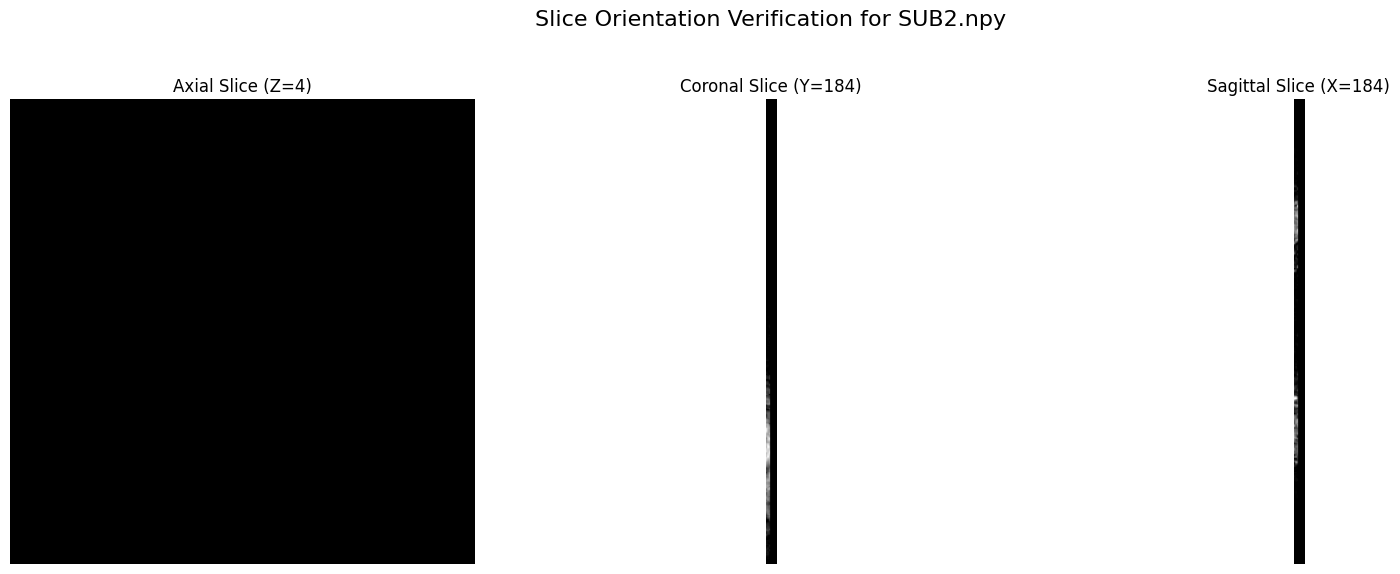


Interpretation: Check if the displayed slices correspond to the expected anatomical views.
  - Axial: Top-down or bottom-up view.
  - Coronal: Front-to-back or back-to-front view.
  - Sagittal: Side-to-side view.


In [36]:
# Re-using image_file_path from earlier cell 'cf4550ea'
# Make sure image_file_path points to a 3D .npy file.
# If the variable is not set, we'll try to find one again.

if 'image_file_path' not in locals() or image_file_path is None:
    print("image_file_path not found or is None. Searching for a sample 3D image file...")
    for root_dir, _, files in os.walk(unzip_path):
        if 'seg3D' in root_dir and 'images' in root_dir:
            for file_name in files:
                if file_name.endswith('.npy'):
                    temp_path = os.path.join(root_dir, file_name)
                    try:
                        temp_data = np.load(temp_path)
                        if temp_data.ndim == 3:
                            image_file_path = temp_path
                            print(f"Found sample 3D image file: {image_file_path}")
                            break
                    except Exception as e:
                        print(f"Could not load {temp_path}: {e}")
            if image_file_path: # Break outer loop if found
                break

if image_file_path and os.path.exists(image_file_path):
    try:
        mri_volume = np.load(image_file_path)

        if mri_volume.ndim != 3:
            print(f"Skipping slice orientation verification: {image_file_path} is not a 3D volume (shape: {mri_volume.shape}).")
        else:
            print(f"Loaded 3D MRI volume from: {image_file_path}")
            print(f"Volume shape: {mri_volume.shape}")

            # Choose a central slice for each dimension for visualization
            dim_x, dim_y, dim_z = mri_volume.shape

            axial_slice_idx = dim_z // 2
            coronal_slice_idx = dim_y // 2
            sagittal_slice_idx = dim_x // 2

            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f'Slice Orientation Verification for {os.path.basename(image_file_path)}', fontsize=16)

            # Axial Slice (typically 2D planes perpendicular to the longest axis)
            axes[0].imshow(mri_volume[:, :, axial_slice_idx], cmap='gray')
            axes[0].set_title(f'Axial Slice (Z={axial_slice_idx})')
            axes[0].axis('off')

            # Coronal Slice (2D planes parallel to the face)
            axes[1].imshow(mri_volume[:, coronal_slice_idx, :], cmap='gray')
            axes[1].set_title(f'Coronal Slice (Y={coronal_slice_idx})')
            axes[1].axis('off')

            # Sagittal Slice (2D planes parallel to the side of the body)
            axes[2].imshow(mri_volume[sagittal_slice_idx, :, :], cmap='gray')
            axes[2].set_title(f'Sagittal Slice (X={sagittal_slice_idx})')
            axes[2].axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
            plt.show()

            print("\nInterpretation: Check if the displayed slices correspond to the expected anatomical views.")
            print("  - Axial: Top-down or bottom-up view.")
            print("  - Coronal: Front-to-back or back-to-front view.")
            print("  - Sagittal: Side-to-side view.")

    except Exception as e:
        print(f"Error loading or displaying MRI volume from {image_file_path}: {e}")
else:
    print("Could not find a valid 3D .npy image file for slice orientation verification.")

### Explicitly Verifying the Depth Axis

Based on common medical imaging conventions, the three dimensions of a 3D MRI volume typically correspond to:

*   **First dimension (index 0):** Often corresponds to the Sagittal plane (left-right or right-left slices).
*   **Second dimension (index 1):** Often corresponds to the Coronal plane (front-back or back-front slices).
*   **Third dimension (index 2):** Often corresponds to the Axial/Transverse plane (head-feet or feet-head slices), representing the 'depth' or number of slices.

However, this can vary depending on how the data was acquired or preprocessed. The previous visualization provided a visual check. This cell will focus on displaying the exact shape of the volume and reiterating the interpretation.

In [37]:
# Re-using image_file_path from earlier cell 'cf4550ea'
# Make sure image_file_path points to a 3D .npy file.
# If the variable is not set, we'll try to find one again.

if 'image_file_path' not in locals() or image_file_path is None:
    print("image_file_path not found or is None. Searching for a sample 3D image file...")
    for root_dir, _, files in os.walk(unzip_path):
        if 'seg3D' in root_dir and 'images' in root_dir:
            for file_name in files:
                if file_name.endswith('.npy'):
                    temp_path = os.path.join(root_dir, file_name)
                    try:
                        temp_data = np.load(temp_path)
                        if temp_data.ndim == 3:
                            image_file_path = temp_path
                            print(f"Found sample 3D image file: {image_file_path}")
                            break
                    except Exception as e:
                        print(f"Could not load {temp_path}: {e}")
            if image_file_path: # Break outer loop if found
                break

if image_file_path and os.path.exists(image_file_path):
    try:
        mri_volume = np.load(image_file_path)

        if mri_volume.ndim != 3:
            print(f"Skipping depth axis verification: {image_file_path} is not a 3D volume (shape: {mri_volume.shape}).")
        else:
            print(f"Loaded 3D MRI volume from: {image_file_path}")
            volume_shape = mri_volume.shape
            print(f"Volume shape: {volume_shape}")

            # Assuming (height, width, depth) for common medical image formats
            # Or (sagittal_slices, coronal_slices, axial_slices)
            print(f"\nInterpretation based on common convention:")
            print(f"  Dimension 0 (shape[0]): {volume_shape[0]} corresponds to the number of slices in the sagittal view (X-axis). ")
            print(f"  Dimension 1 (shape[1]): {volume_shape[1]} corresponds to the number of slices in the coronal view (Y-axis).")
            print(f"  Dimension 2 (shape[2]): {volume_shape[2]} corresponds to the number of slices in the axial view (Z-axis, often considered the 'depth').")

            print(f"\nGiven the shape {volume_shape}, the third dimension (index 2) with size {volume_shape[2]} is most likely the 'depth' axis from which individual axial slices are taken.")

    except Exception as e:
        print(f"Error loading or inspecting MRI volume from {image_file_path}: {e}")
else:
    print("Could not find a valid 3D .npy image file for depth axis verification.")

Loaded 3D MRI volume from: /content/BreastDMDS_unzipped/seg3D/train/images/BreaDM-Ma-1913/SUB2.npy
Volume shape: (369, 369, 8)

Interpretation based on common convention:
  Dimension 0 (shape[0]): 369 corresponds to the number of slices in the sagittal view (X-axis). 
  Dimension 1 (shape[1]): 369 corresponds to the number of slices in the coronal view (Y-axis).
  Dimension 2 (shape[2]): 8 corresponds to the number of slices in the axial view (Z-axis, often considered the 'depth').

Given the shape (369, 369, 8), the third dimension (index 2) with size 8 is most likely the 'depth' axis from which individual axial slices are taken.


### Counting Images and Masks in `segmentation_dataset_v2`

This script will count the total number of image and mask files in the newly generated `segmentation_dataset_v2` to verify that all slices have been correctly extracted and that the number of images matches the number of masks.

In [38]:
# Define the paths to the images and masks directories in segmentation_dataset_v2
segmentation_dataset_root_v2 = '/content/segmentation_dataset_v2'
images_dir_v2 = os.path.join(segmentation_dataset_root_v2, 'images')
masks_dir_v2 = os.path.join(segmentation_dataset_root_v2, 'masks')

# Check if the directories exist
if not os.path.exists(images_dir_v2):
    print(f"Error: Image directory not found at {images_dir_v2}")
    image_count = 0
else:
    image_count = len(os.listdir(images_dir_v2))
    print(f"Total images in '{images_dir_v2}': {image_count}")

if not os.path.exists(masks_dir_v2):
    print(f"Error: Mask directory not found at {masks_dir_v2}")
    mask_count = 0
else:
    mask_count = len(os.listdir(masks_dir_v2))
    print(f"Total masks in '{masks_dir_v2}': {mask_count}")

# Verify if the counts are equal
if image_count > 0 and mask_count > 0 and image_count == mask_count:
    print("\nVerification Successful: The number of image files matches the number of mask files!")
elif image_count == 0 and mask_count == 0:
    print("\nWarning: No image or mask files found. Please ensure the previous processing step was successful.")
else:
    print("\nWarning: The number of image files does NOT match the number of mask files. Further investigation may be needed.")

Total images in '/content/segmentation_dataset_v2/images': 5568
Total masks in '/content/segmentation_dataset_v2/masks': 5568

Verification Successful: The number of image files matches the number of mask files!
